# 05: Weighting, Overlap, and Common Support

We focus on the diagnostic side of propensity weighting. Inverse propensity weighting can be powerful, but it becomes fragile when treated and untreated units do not overlap. If some users are almost certain to receive treatment, or almost certain not to receive treatment, the data contain weak comparisons for those users.

We will compare two synthetic observational datasets: one with usable overlap and one with weak overlap. The causal graph and true treatment effect are the same in both cases. What changes is how separable the treated and untreated groups are.


## Learning Goals

By the end, you should be able to:

- Explain overlap, common support, and positivity in practical language.
- Estimate propensity scores and inspect treated-control overlap.
- Compute inverse propensity weights, stabilized weights, normalized IPW, and trimmed IPW estimates.
- Use effective sample size to see when weights are fragile.
- Compare raw and weighted covariate balance.
- Understand why a weighting estimator can become unstable even when the causal graph is correct.
- Run DoWhy's propensity-score weighting estimator and read it alongside manual diagnostics.


## Dataset and Experiment Setup

<!-- dataset-experiment-note -->

We use mostly simulated or semi-synthetic observational datasets to study **Weighting, Overlap, And Common Support**. DoWhy is mainly about causal modeling discipline: graph, estimand, estimator, and refuter. A controlled dataset lets us show how a change in assumptions changes the estimand and the credibility of the estimate.

Read each row as an observed unit in a business or policy system. The treatment, outcome, common causes, instruments, mediators, and anomaly indicators are named to mirror applied causal workflows and keep the examples close to realistic analysis language. The experiment uses weights to construct a more comparable pseudo-population. Extreme weights are treated as evidence about the design, more than a numerical nuisance. The experiment is deliberately sensitive to common support. Units with weak overlap teach why some causal questions are poorly supported by the observed data.

The simulation is designed to make the identifying assumptions and diagnostic checks visible. It is meant to expose the assumptions that would be hidden in real data, where the true counterfactual outcome is unavailable.


## Mathematical Foundation

<!-- math-foundation-note -->

For binary treatment, the average treatment effect is

$$
\tau=\mathbb{E}\{Y(1)-Y(0)\}.
$$

Under conditional exchangeability, positivity, and consistency,

$$
\tau=\mathbb{E}_X\left[\mathbb{E}(Y\mid D=1,X)-\mathbb{E}(Y\mid D=0,X)\right].
$$

Matching, regression, and weighting are different computational routes to this adjusted contrast.


## Why Overlap Matters

Backdoor adjustment compares treated and untreated units with similar observed covariates. Propensity weighting does this by giving each unit a weight based on how surprising its observed treatment status was.

If a treated unit had a very low probability of being treated, its treated observation is rare and receives a large weight. If an untreated unit had a very high probability of being treated, its untreated observation is rare and receives a large weight. A few very large weights can dominate the estimate.

That is the practical overlap problem: the math may still run, but the estimate is supported by too few comparable observations.





## Tutorial Workflow

#### Setup

This setup block imports the packages used in the lesson, creates output folders, fixes a random seed, and suppresses known third-party compatibility warnings. The warning policy keeps expected library chatter out of the student-facing material while preserving real execution errors.


In [ ]:
# Build and label the diagnostic visualization for the Setup section.
from pathlib import Path
import os
import platform
import sys
import warnings
START_DIR = Path.cwd().resolve()
PROJECT_ROOT = next(
    (candidate for candidate in [START_DIR, *START_DIR.parents] if (candidate / "pyproject.toml").exists()),
    START_DIR,
)
NOTEBOOK_DIR = PROJECT_ROOT / "notebooks" / "tutorials" / "dowhy"
OUTPUT_DIR = NOTEBOOK_DIR / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
CACHE_DIR = PROJECT_ROOT / ".cache" / "matplotlib"
for directory in [OUTPUT_DIR, FIGURE_DIR, TABLE_DIR, CACHE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(CACHE_DIR))
warnings.filterwarnings("default")
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=PendingDeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*IProgress not found.*")
warnings.filterwarnings("ignore", message=".*setParseAction.*deprecated.*")
warnings.filterwarnings("ignore", message=".*copy keyword is deprecated.*")
warnings.filterwarnings("ignore", message=".*disp.*iprint.*L-BFGS-B.*")
warnings.filterwarnings("ignore", module="dowhy.causal_estimators.regression_estimator")
warnings.filterwarnings("ignore", module="sklearn.linear_model._logistic")
warnings.filterwarnings("ignore", module="seaborn.categorical")
warnings.filterwarnings("ignore", module="pydot.dot_parser")
import numpy as np
import pandas as pd
import networkx as nx
# Compatibility shim for DoWhy versions that expect the older NetworkX d_separated API.
if not hasattr(nx.algorithms, "d_separated"):
    from networkx.algorithms.d_separation import is_d_separator
    nx.algorithms.d_separated = is_d_separator
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 0)
# Compatibility shim for DoWhy estimators written against older pandas Series integer indexing.
if not getattr(pd.Series, "_dowhy_integer_position_patch", False):
    _original_series_getitem = pd.Series.__getitem__
    def _dowhy_series_getitem_compat(self, key):
        try:
            return _original_series_getitem(self, key)
        except KeyError:
            if isinstance(key, int) and key not in self.index:
                return self.iloc[key]
            raise
    pd.Series.__getitem__ = _dowhy_series_getitem_compat
    pd.Series._dowhy_integer_position_patch = True
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import dowhy
from dowhy import CausalModel
RANDOM_SEED = 55
rng = np.random.default_rng(RANDOM_SEED)
sns.set_theme(style="whitegrid", context="notebook")
print(f"Python executable: {sys.executable}")
print(f"Python version: {platform.python_version()}")
print(f"DoWhy version: {getattr(dowhy, '__version__', 'unknown')}")
print(f"Notebook directory: {NOTEBOOK_DIR}")


The lesson is ready if this step prints a DoWhy version. All generated outputs from this lesson use a `05_` prefix.

This reproducibility check keeps the run auditable before causal interpretation begins. It makes the run consistent enough for later graphs, tables, and estimates to be checked against the same environment.
<!-- result-implication-expanded -->


### Key Concepts

This table defines the vocabulary used throughout the lesson. These terms often appear together, but they answer slightly different diagnostic questions.


| concept | plain_language | why_it_matters |
| --- | --- | --- |
| Propensity score | The probability of receiving treatment given observed covariates. | It summarizes observed treatment selection into one balancing score. |
| Overlap | Treated and untreated units exist at similar covariate or propensity values. | Without overlap, comparisons require extrapolation. |
| Common support | The region of propensity scores where both treatment groups are represented. | Estimates outside common support are weakly supported by data. |
| Positivity | Every covariate profile has a nonzero chance of receiving each treatment level. | If treatment is deterministic for some profiles, causal contrasts cannot be learned from observed data there. |
| Extreme weights | Very large inverse propensity weights from near-zero or near-one propensities. | A few units can dominate the estimate and inflate variance. |
| Effective sample size | The sample size implied by the concentration of weights. | A nominally large dataset can behave like a much smaller one after weighting. |


The headline idea is straightforward. Weighting is about more than computing a formula. It also requires checking whether the weighted comparison is supported by enough comparable observations.


#### Causal Question and Variable Roles

The causal question is the same in both overlap scenarios:

> What is the average effect of `feature_exposure` on `weekly_value`?

The graph assumes all adjustment variables are observed pre-treatment common causes.


| variable | role | timing | adjustment_guidance |
| --- | --- | --- | --- |
| feature_exposure | treatment | treatment time | treatment, not a control |
| weekly_value | outcome | future outcome window | outcome, not a control |
| user_engagement | observed common cause | pre-treatment | adjust |
| prior_sessions | observed common cause | pre-treatment | adjust |
| account_age_weeks | observed common cause | pre-treatment | adjust |
| is_power_user | observed common cause | pre-treatment | adjust |
| baseline_value | observed common cause | pre-treatment | adjust |
| true_propensity | simulation diagnostic | known only because this is simulated | do not use as a real observed column |


The same roles apply in both simulated scenarios. This is important: the graph can be correct and the adjustment set can be right, while weighting is still unstable because overlap is weak.





## Diagnostics and Interpretation

#### Create Two Overlap Scenarios

This function creates two datasets with the same outcome equation and the same true causal effect. The only difference is treatment-selection strength.

- In the usable-overlap case, baseline variables influence treatment, but not so strongly that treatment is almost deterministic.
- In the weak-overlap case, baseline variables strongly separate treated and untreated users.


In [2]:
# Define reusable helpers for the Create Two Overlap Scenarios section.
def make_overlap_data(n=5_000, treatment_selection_strength=0.55, seed=55, scenario="usable_overlap"):
    """
    Idea: Construct the overlap data used in the Create Two Overlap Scenarios section, including columns needed for later diagnostics.
    
    Parameters
    ----------
    n : int
        Number of observations or repetitions to generate.
    treatment_selection_strength : object
        Context-specific input used for treatment selection strength in this helper.
    seed : int
        Random seed used to make generation or resampling reproducible.
    scenario : str
        Scenario label describing the data-generating or diagnostic condition.
    
    Returns
    -------
    tuple
        Tuple containing pd.DataFrame({'scenario': scenario, 'feature_exposure': feature_exposure, 'weekly_value': weekly_value, 'user_engagement': user_engagement, 'prior_sessions': prior_sessions, 'account_age_weeks': account_age_weeks, 'is_power_user': is_power_user, 'baseline_value': baseline_value, 'true_propensity': true_propensity}), true_ate, aligned for the causal estimator.
    """
    local_rng = np.random.default_rng(seed)
    user_engagement = local_rng.normal(loc=0.0, scale=1.0, size=n)
    prior_sessions = np.clip(
        local_rng.poisson(lam=np.exp(1.0 + 0.20 * user_engagement), size=n),
        0,
        30,
    )
    account_age_weeks = local_rng.gamma(shape=2.2, scale=3.5, size=n)
    is_power_user = local_rng.binomial(
        n=1,
        p=1 / (1 + np.exp(-(0.75 * user_engagement - 0.20))),
        size=n,
    )
    baseline_value = (
        2.0
        + 1.00 * user_engagement
        + 0.050 * prior_sessions
        + 0.020 * account_age_weeks
        + 0.550 * is_power_user
        + local_rng.normal(loc=0.0, scale=1.0, size=n)
    )
    selection_score = (
        0.90 * user_engagement
        + 0.050 * prior_sessions
        + 0.200 * baseline_value
        + 0.550 * is_power_user
        - 0.015 * account_age_weeks
    )
    treatment_logit = -0.55 + treatment_selection_strength * selection_score
    true_propensity = 1 / (1 + np.exp(-treatment_logit))
    feature_exposure = local_rng.binomial(n=1, p=true_propensity, size=n)
    true_ate = 1.60
    weekly_value = (
        4.0
        + true_ate * feature_exposure
        + 1.20 * user_engagement
        + 0.060 * prior_sessions
        + 0.030 * account_age_weeks
        + 0.600 * baseline_value
        + 0.450 * is_power_user
        + local_rng.normal(loc=0.0, scale=1.20, size=n)
    )
    return pd.DataFrame(
        {
            "scenario": scenario,
            "feature_exposure": feature_exposure,
            "weekly_value": weekly_value,
            "user_engagement": user_engagement,
            "prior_sessions": prior_sessions,
            "account_age_weeks": account_age_weeks,
            "is_power_user": is_power_user,
            "baseline_value": baseline_value,
            "true_propensity": true_propensity,
        }
    ), true_ate
usable_df, TRUE_ATE = make_overlap_data(treatment_selection_strength=0.55, seed=55, scenario="usable_overlap")
weak_df, _ = make_overlap_data(treatment_selection_strength=2.20, seed=56, scenario="weak_overlap")
overlap_df = pd.concat([usable_df, weak_df], ignore_index=True)
overlap_df.to_csv(TABLE_DIR / "05_overlap_teaching_dataset.csv", index=False)
print(f"Rows: {len(overlap_df):,}")
print(f"Known true ATE in both scenarios: {TRUE_ATE:.4f}")
overlap_df.head()


Rows: 10,000
Known true ATE in both scenarios: 1.6000


,scenario,feature_exposure,weekly_value,user_engagement,prior_sessions,account_age_weeks,is_power_user,baseline_value,true_propensity
0,usable_overlap,1,9.855097,0.842261,1,8.283946,0,3.686182,0.557632
1,usable_overlap,1,2.480982,-2.976111,5,6.161959,0,-0.600032,0.118939
2,usable_overlap,1,6.655229,-0.305024,6,13.987074,0,2.533541,0.407891
3,usable_overlap,1,12.785204,1.449888,5,18.359764,0,4.458250,0.655687
4,usable_overlap,0,4.590193,-1.243961,2,10.443849,0,2.352953,0.281285


Both scenarios have the same true treatment effect. If estimates behave differently, the difference is coming from treatment assignment and overlap, not from a different causal effect.





## Reporting and Takeaways

### Scenario Summary

This table compares treatment rates and true propensity ranges across the two scenarios.


In [3]:
scenario_summary = (
    overlap_df.groupby("scenario")
    .agg(
        rows=("weekly_value", "size"),
        treatment_rate=("feature_exposure", "mean"),
        outcome_mean=("weekly_value", "mean"),
        true_propensity_min=("true_propensity", "min"),
        true_propensity_p01=("true_propensity", lambda s: s.quantile(0.01)),
        true_propensity_median=("true_propensity", "median"),
        true_propensity_p99=("true_propensity", lambda s: s.quantile(0.99)),
        true_propensity_max=("true_propensity", "max"),
    )
    .reset_index()
)
scenario_summary.to_csv(TABLE_DIR / "05_scenario_summary.csv", index=False)
scenario_summary


,scenario,rows,treatment_rate,outcome_mean,true_propensity_min,true_propensity_p01,true_propensity_median,true_propensity_p99,true_propensity_max
0,usable_overlap,5000,0.4678,6.831726,0.078186,0.152451,0.464421,0.819403,0.920257
1,weak_overlap,5000,0.6260,7.164682,0.000377,0.005390,0.758453,0.999701,0.999956


The weak-overlap scenario has propensities much closer to zero and one. That means some treated or untreated observations will receive much larger inverse-propensity weights.




### Estimate Propensity Scores in Each Scenario

In real observational data we do not know true propensities, so we estimate them. The code below fits a separate logistic propensity model in each scenario using the same observed common causes.


In [4]:
# Fit or evaluate the model objects used in the Estimate Propensity Scores In Each Scenario section.
confounder_cols = ["user_engagement", "prior_sessions", "account_age_weeks", "is_power_user", "baseline_value"]
scored_parts = []
propensity_model_rows = []
for scenario, scenario_df in overlap_df.groupby("scenario"):
    X = scenario_df[confounder_cols]
    treatment = scenario_df["feature_exposure"]
    propensity_model = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1_000, random_state=RANDOM_SEED),
    )
    propensity_model.fit(X, treatment)
    estimated_propensity = propensity_model.predict_proba(X)[:, 1]
    scenario_scored = scenario_df.copy()
    scenario_scored["estimated_propensity"] = estimated_propensity
    scenario_scored["clipped_propensity_01"] = np.clip(estimated_propensity, 0.01, 0.99)
    scenario_scored["clipped_propensity_05"] = np.clip(estimated_propensity, 0.05, 0.95)
    scored_parts.append(scenario_scored)
    propensity_model_rows.append(
        {
            "scenario": scenario,
            "propensity_auc": roc_auc_score(treatment, estimated_propensity),
            "estimated_propensity_min": estimated_propensity.min(),
            "estimated_propensity_p01": np.quantile(estimated_propensity, 0.01),
            "estimated_propensity_median": np.median(estimated_propensity),
            "estimated_propensity_p99": np.quantile(estimated_propensity, 0.99),
            "estimated_propensity_max": estimated_propensity.max(),
        }
    )
scored_df = pd.concat(scored_parts, ignore_index=True)
propensity_model_summary = pd.DataFrame(propensity_model_rows)
scored_df.to_csv(TABLE_DIR / "05_scored_overlap_dataset.csv", index=False)
propensity_model_summary.to_csv(TABLE_DIR / "05_propensity_model_summary.csv", index=False)
propensity_model_summary


,scenario,propensity_auc,estimated_propensity_min,estimated_propensity_p01,estimated_propensity_median,estimated_propensity_p99,estimated_propensity_max
0,usable_overlap,0.687405,0.081002,0.155716,0.460928,0.814791,0.910762
1,weak_overlap,0.917156,0.000352,0.004665,0.752000,0.999692,0.999958


The weak-overlap scenario should have a higher propensity-model AUC because treatment assignment is easier to predict. For causal weighting, easier treatment prediction often means weaker overlap.


### Plot Propensity Overlap

This plot compares treated and untreated propensity distributions in each scenario. Good overlap means both groups occupy similar regions of the propensity scale.


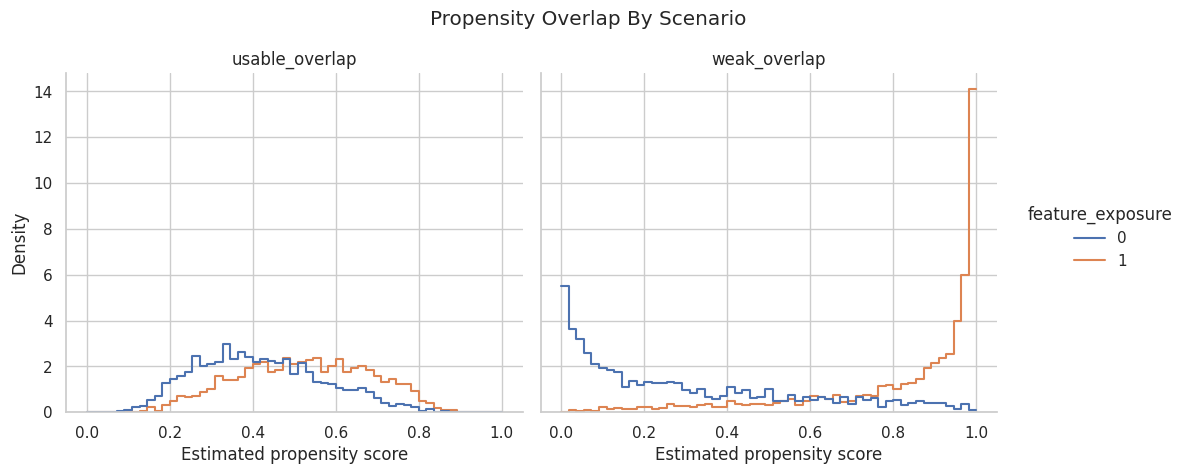

In [5]:
g = sns.displot(
    data=scored_df,
    x="estimated_propensity",
    hue="feature_exposure",
    col="scenario",
    bins=55,
    stat="density",
    common_norm=False,
    element="step",
    fill=False,
    height=4.5,
    aspect=1.15,
)
g.set_axis_labels("Estimated propensity score", "Density")
g.set_titles("{col_name}")
g.fig.suptitle("Propensity Overlap By Scenario", y=1.05)
g.fig.savefig(FIGURE_DIR / "05_propensity_overlap_by_scenario.png", dpi=160, bbox_inches="tight")
plt.show()


The weak-overlap panel should show more separation. That separation is the visual warning that weighting will rely on a smaller, more fragile set of comparable observations.


### Common Support Diagnostics

Common support asks whether treated and untreated users exist over the same propensity range. The code below summarizes overlap using min/max ranges and the share of observations inside simple trimming bands.


In [6]:
# Define reusable helpers for the Common Support Diagnostics section.
def common_support_summary(df):
    """
    Idea: Assemble a summary of the common support summary with the quantities needed for interpretation.
    
    Parameters
    ----------
    df : pd.DataFrame
        Rows used by this helper.
    
    Returns
    -------
    pd.DataFrame
        Support table showing how many observations remain under each propensity trimming rule.
    """
    rows = []
    for scenario, scenario_df in df.groupby("scenario"):
        treated_ps = scenario_df.loc[scenario_df["feature_exposure"] == 1, "estimated_propensity"]
        control_ps = scenario_df.loc[scenario_df["feature_exposure"] == 0, "estimated_propensity"]
        lower_support = max(treated_ps.min(), control_ps.min())
        upper_support = min(treated_ps.max(), control_ps.max())
        in_empirical_support = scenario_df["estimated_propensity"].between(lower_support, upper_support)
        rows.append(
            {
                "scenario": scenario,
                "treated_ps_min": treated_ps.min(),
                "treated_ps_max": treated_ps.max(),
                "control_ps_min": control_ps.min(),
                "control_ps_max": control_ps.max(),
                "empirical_common_support_lower": lower_support,
                "empirical_common_support_upper": upper_support,
                "share_inside_empirical_common_support": in_empirical_support.mean(),
                "share_inside_01_99_band": scenario_df["estimated_propensity"].between(0.01, 0.99).mean(),
                "share_inside_05_95_band": scenario_df["estimated_propensity"].between(0.05, 0.95).mean(),
                "share_inside_10_90_band": scenario_df["estimated_propensity"].between(0.10, 0.90).mean(),
            }
        )
    return pd.DataFrame(rows)
support_summary = common_support_summary(scored_df)
support_summary.to_csv(TABLE_DIR / "05_common_support_summary.csv", index=False)
support_summary


,scenario,treated_ps_min,treated_ps_max,control_ps_min,control_ps_max,empirical_common_support_lower,empirical_common_support_upper,share_inside_empirical_common_support,share_inside_01_99_band,share_inside_05_95_band,share_inside_10_90_band
0,usable_overlap,0.095802,0.910762,0.081002,0.872378,0.095802,0.872378,0.9980,1.000,1.000,0.9986
1,weak_overlap,0.023944,0.999958,0.000352,0.999121,0.023944,0.999121,0.9312,0.861,0.652,0.5194


The trimming-band shares show how much data would remain if we restricted analysis to less extreme propensity regions. Trimming improves stability, but it changes the target population.




### Compute Weights and Effective Sample Size

The code below computes several weight variants:

- Plain inverse propensity weights.
- Stabilized weights, which multiply by marginal treatment probabilities.
- Clipped weights, using propensities clipped to `[0.01, 0.99]` and `[0.05, 0.95]`.

It also computes effective sample size, which falls when weights concentrate on a few units.


In [7]:
# Define reusable helpers for the Compute Weights And Effective Sample Size section.
def add_weight_columns(df):
    """
    Idea: Compute the weight columns needed in the Compute Weights And Effective Sample Size section and return it in a form the next cells can inspect.
    
    Parameters
    ----------
    df : pd.DataFrame
        Rows used by this helper.
    
    Returns
    -------
    pd.DataFrame
        DataFrame with propensity, IPW, stabilized-weight, and trimming columns attached.
    """
    weighted_parts = []
    for scenario, scenario_df in df.groupby("scenario"):
        part = scenario_df.copy()
        treatment = part["feature_exposure"].to_numpy()
        p_treated = treatment.mean()
        for propensity_col, suffix in [
            ("estimated_propensity", "raw"),
            ("clipped_propensity_01", "clip01"),
            ("clipped_propensity_05", "clip05"),
        ]:
            propensity = part[propensity_col].to_numpy()
            part[f"ipw_weight_{suffix}"] = treatment / propensity + (1 - treatment) / (1 - propensity)
            part[f"stabilized_weight_{suffix}"] = (
                treatment * p_treated / propensity
                + (1 - treatment) * (1 - p_treated) / (1 - propensity)
            )
        weighted_parts.append(part)
    return pd.concat(weighted_parts, ignore_index=True)
def effective_sample_size(weights):
    """
    Idea: Summarize how concentrated a set of weights is by converting it to an effective sample size.
    
    Parameters
    ----------
    weights : array-like
        Observation weights defining the target population or policy objective.
    
    Returns
    -------
    float
        Effective sample size implied by the concentration of the weights.
    """
    weights = np.asarray(weights)
    return weights.sum() ** 2 / np.sum(weights ** 2)
weighted_df = add_weight_columns(scored_df)
weight_rows = []
for scenario, scenario_df in weighted_df.groupby("scenario"):
    for weight_col in [
        "ipw_weight_raw",
        "ipw_weight_clip01",
        "ipw_weight_clip05",
        "stabilized_weight_raw",
        "stabilized_weight_clip01",
        "stabilized_weight_clip05",
    ]:
        weights = scenario_df[weight_col]
        weight_rows.append(
            {
                "scenario": scenario,
                "weight_column": weight_col,
                "mean_weight": weights.mean(),
                "max_weight": weights.max(),
                "p95_weight": weights.quantile(0.95),
                "p99_weight": weights.quantile(0.99),
                "effective_sample_size": effective_sample_size(weights),
                "nominal_sample_size": len(weights),
                "ess_share_of_nominal": effective_sample_size(weights) / len(weights),
            }
        )
weight_diagnostics = pd.DataFrame(weight_rows)
weighted_df.to_csv(TABLE_DIR / "05_weighted_overlap_dataset.csv", index=False)
weight_diagnostics.to_csv(TABLE_DIR / "05_weight_diagnostics.csv", index=False)
weight_diagnostics


,scenario,weight_column,mean_weight,max_weight,p95_weight,p99_weight,effective_sample_size,nominal_sample_size,ess_share_of_nominal
0,usable_overlap,ipw_weight_raw,2.000951,10.438142,3.501863,4.870062,4328.470395,5000,0.865694
1,usable_overlap,ipw_weight_clip01,2.000951,10.438142,3.501863,4.870062,4328.470395,5000,0.865694
2,usable_overlap,ipw_weight_clip05,2.000951,10.438142,3.501863,4.870062,4328.470395,5000,0.865694
3,usable_overlap,stabilized_weight_raw,1.000354,4.882963,1.725269,2.411711,4357.480619,5000,0.871496
4,usable_overlap,stabilized_weight_clip01,1.000354,4.882963,1.725269,2.411711,4357.480619,5000,0.871496
5,usable_overlap,stabilized_weight_clip05,1.000354,4.882963,1.725269,2.411711,4357.480619,5000,0.871496
6,weak_overlap,ipw_weight_raw,2.093583,1138.156700,4.347776,11.870133,79.118850,5000,0.015824
7,weak_overlap,ipw_weight_clip01,1.876280,100.000000,4.347776,11.870133,1019.649847,5000,0.203930
8,weak_overlap,ipw_weight_clip05,1.771379,20.000000,4.347776,11.870133,2108.846973,5000,0.421769
9,weak_overlap,stabilized_weight_raw,1.026361,425.670606,2.179343,6.013635,132.610950,5000,0.026522


The weak-overlap scenario should have larger maximum weights and a smaller effective sample size. A nominal sample of thousands can behave like a much smaller sample if a few units receive huge weights.




#### Plot Weight Distributions

Weights are easier to diagnose on a log scale because the right tail is what usually causes trouble.


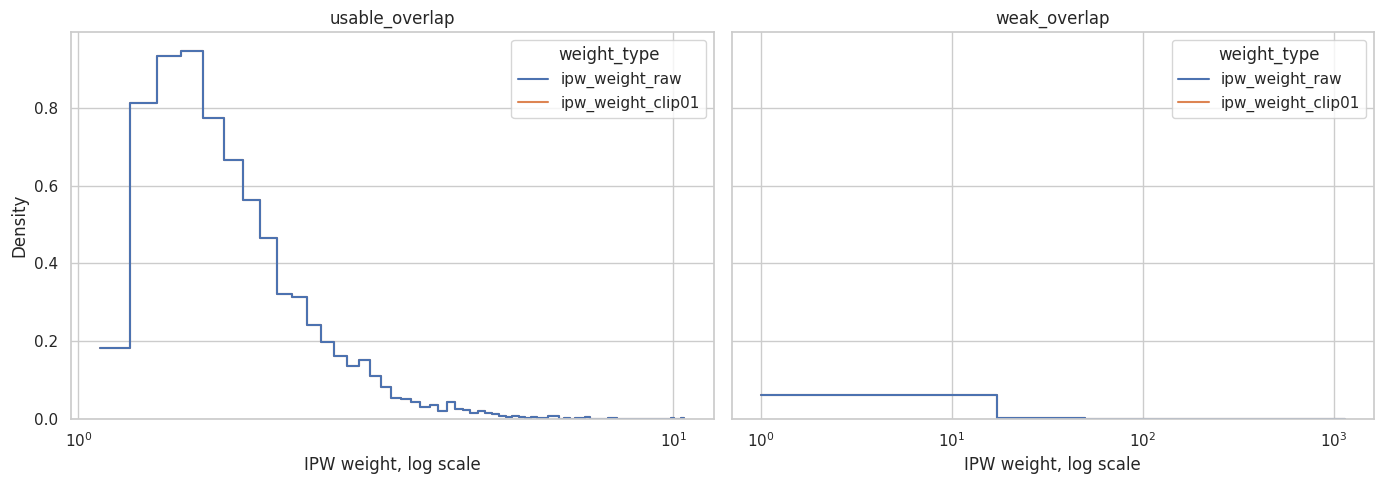

In [8]:
# Build and label the diagnostic visualization for the Plot Weight Distributions section.
weight_plot_df = weighted_df[["scenario", "feature_exposure", "ipw_weight_raw", "ipw_weight_clip01", "ipw_weight_clip05"]].melt(
    id_vars=["scenario", "feature_exposure"],
    var_name="weight_type",
    value_name="weight",
)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, scenario in zip(axes, ["usable_overlap", "weak_overlap"]):
    scenario_plot = weight_plot_df.query("scenario == @scenario and weight_type in ['ipw_weight_raw', 'ipw_weight_clip01']")
    sns.histplot(
        data=scenario_plot,
        x="weight",
        hue="weight_type",
        bins=70,
        stat="density",
        common_norm=False,
        element="step",
        fill=False,
        ax=ax,
    )
    ax.set_xscale("log")
    ax.set_title(scenario)
    ax.set_xlabel("IPW weight, log scale")
    ax.set_ylabel("Density")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "05_weight_distributions.png", dpi=160, bbox_inches="tight")
plt.show()


The weak-overlap scenario should have a heavier right tail. Those high-weight observations are the units that make the weighting estimator more fragile.

For causal interpretation, this support check shows when weak overlap may force an estimator to extrapolate beyond comparable treated and control units.
<!-- result-implication-expanded -->


#### Balance Before and After Weighting

A good weighting model should reduce imbalance in observed covariates. The code below compares raw balance to IPW-weighted balance using standardized mean differences.


In [9]:
# Define reusable helpers for the Balance Before And After Weighting section.
def weighted_mean(values, weights):
    """
    Idea: Compute a mean that reflects the target population or policy weighting scheme.
    
    Parameters
    ----------
    values : object
        Numeric values being transformed, summarized, or plotted.
    weights : array-like
        Observation weights defining the target population or policy objective.
    
    Returns
    -------
    float
        Weighted average of the supplied values.
    """
    values = np.asarray(values)
    weights = np.asarray(weights)
    return np.sum(values * weights) / np.sum(weights)
def weighted_var(values, weights):
    """
    Idea: Compute the weighted variance used by the balance or uncertainty diagnostic.
    
    Parameters
    ----------
    values : object
        Numeric values being transformed, summarized, or plotted.
    weights : array-like
        Observation weights defining the target population or policy objective.
    
    Returns
    -------
    float
        Weighted variance around the supplied or computed weighted mean.
    """
    values = np.asarray(values)
    weights = np.asarray(weights)
    mean = weighted_mean(values, weights)
    return np.sum(weights * (values - mean) ** 2) / np.sum(weights)
def standardized_mean_difference(df, column, weights=None):
    """
    Idea: Measure covariate imbalance as a treated-control mean difference on a pooled-standard-deviation scale.
    
    Parameters
    ----------
    df : pd.DataFrame
        Rows used by this helper.
    column : object
        Column name selected from the DataFrame for this calculation.
    weights : array-like
        Observation weights defining the target population or policy objective.
    
    Returns
    -------
    float
        Covariate-balance statistic on a pooled-standard-deviation scale.
    """
    treatment = df["feature_exposure"].to_numpy() == 1
    values = df[column].to_numpy()
    if weights is None:
        treated_values = values[treatment]
        control_values = values[~treatment]
        pooled_sd = np.sqrt((treated_values.var(ddof=1) + control_values.var(ddof=1)) / 2)
        return (treated_values.mean() - control_values.mean()) / pooled_sd
    weights = np.asarray(weights)
    treated_mean = weighted_mean(values[treatment], weights[treatment])
    control_mean = weighted_mean(values[~treatment], weights[~treatment])
    treated_var = weighted_var(values[treatment], weights[treatment])
    control_var = weighted_var(values[~treatment], weights[~treatment])
    pooled_sd = np.sqrt((treated_var + control_var) / 2)
    return (treated_mean - control_mean) / pooled_sd
confounder_cols = ["user_engagement", "prior_sessions", "account_age_weeks", "is_power_user", "baseline_value"]
balance_rows = []
for scenario, scenario_df in weighted_df.groupby("scenario"):
    for covariate in confounder_cols:
        balance_rows.append(
            {
                "scenario": scenario,
                "covariate": covariate,
                "raw_smd": standardized_mean_difference(scenario_df, covariate),
                "weighted_smd_clip01": standardized_mean_difference(
                    scenario_df,
                    covariate,
                    weights=scenario_df["ipw_weight_clip01"].to_numpy(),
                ),
                "weighted_smd_clip05": standardized_mean_difference(
                    scenario_df,
                    covariate,
                    weights=scenario_df["ipw_weight_clip05"].to_numpy(),
                ),
            }
        )
balance_table = pd.DataFrame(balance_rows)
balance_table.to_csv(TABLE_DIR / "05_balance_before_after_weighting.csv", index=False)
balance_table


,scenario,covariate,raw_smd,weighted_smd_clip01,weighted_smd_clip05
0,usable_overlap,user_engagement,0.646501,-0.006006,-0.006006
1,usable_overlap,prior_sessions,0.264855,0.005227,0.005227
2,usable_overlap,account_age_weeks,-0.027640,-0.002722,-0.002722
3,usable_overlap,is_power_user,0.389441,-0.000155,-0.000155
4,usable_overlap,baseline_value,0.556563,-0.001766,-0.001766
5,weak_overlap,user_engagement,1.737636,0.263999,0.504594
6,weak_overlap,prior_sessions,0.502664,0.077280,0.148370
7,weak_overlap,account_age_weeks,-0.050817,0.001329,0.013894
8,weak_overlap,is_power_user,0.881697,0.161302,0.296004
9,weak_overlap,baseline_value,1.433895,0.152070,0.369736


Weighted SMDs should move toward zero if the propensity model is balancing observed covariates. Balance can improve even when weights are unstable, so balance and weight diagnostics should be read together.


#### Plot Balance Diagnostics

This plot compares raw and weighted standardized mean differences across scenarios.


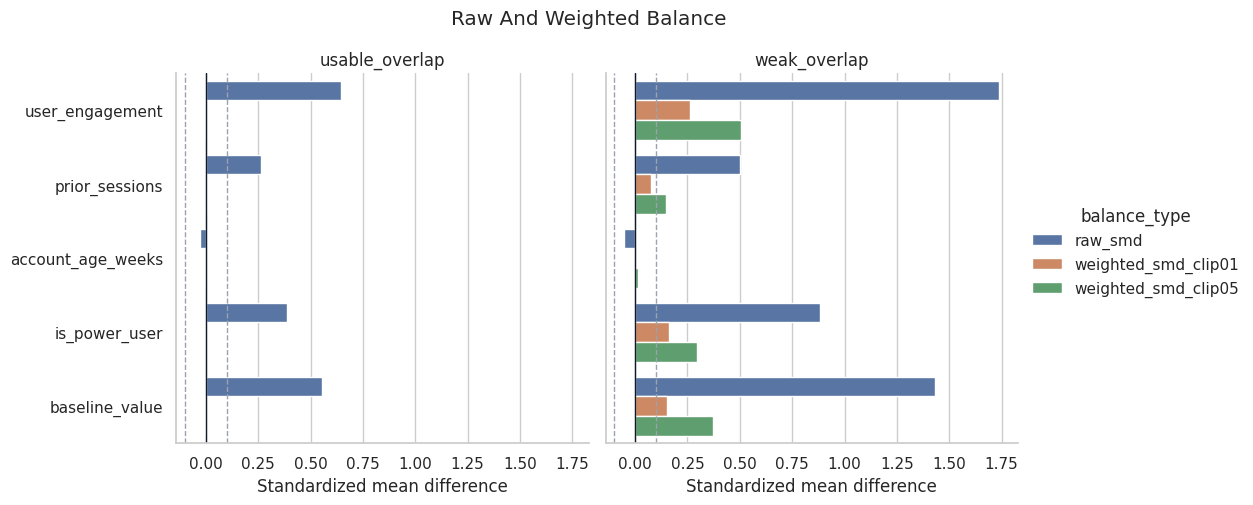

In [10]:
# Build and label the diagnostic visualization for the Plot Balance Diagnostics section.
balance_plot_df = balance_table.melt(
    id_vars=["scenario", "covariate"],
    value_vars=["raw_smd", "weighted_smd_clip01", "weighted_smd_clip05"],
    var_name="balance_type",
    value_name="smd",
)
g = sns.catplot(
    data=balance_plot_df,
    x="smd",
    y="covariate",
    hue="balance_type",
    col="scenario",
    kind="bar",
    height=4.8,
    aspect=1.15,
    sharex=True,
)
for ax in g.axes.flat:
    ax.axvline(0, color="#111827", linewidth=1)
    ax.axvline(0.1, color="#9ca3af", linestyle="--", linewidth=1)
    ax.axvline(-0.1, color="#9ca3af", linestyle="--", linewidth=1)
g.set_axis_labels("Standardized mean difference", "")
g.set_titles("{col_name}")
g.fig.suptitle("Raw And Weighted Balance", y=1.05)
g.fig.savefig(FIGURE_DIR / "05_balance_before_after_weighting.png", dpi=160, bbox_inches="tight")
plt.show()


The weighted bars should shrink compared with the raw bars. If weighting balances covariates but the effective sample size collapses, the estimate may still be too fragile to trust without qualification.




#### Weighting Estimates Across Scenarios

Now we compute treatment-effect estimates for each scenario. The table includes:

- Naive treated-minus-control difference.
- Adjusted outcome regression.
- IPW using clipped propensities.
- Normalized IPW.
- Stabilized-weight outcome mean difference.
- Trimmed normalized IPW restricted to common propensity bands.


In [11]:
# Define reusable helpers for the Weighting Estimates Across Scenarios section.
def estimate_weighted_effects(df, true_ate):
    """
    Idea: Estimate the estimate weighted effects target from the prepared data and return a comparison-ready summary.
    
    Parameters
    ----------
    df : pd.DataFrame
        Rows used by this helper.
    true_ate : object
        Context-specific input used for true ATE in this helper.
    
    Returns
    -------
    pd.DataFrame
        Weighted-effect comparison table across weighting and trimming strategies.
    """
    rows = []
    for scenario, scenario_df in df.groupby("scenario"):
        treatment = scenario_df["feature_exposure"].to_numpy()
        outcome = scenario_df["weekly_value"].to_numpy()
        p01 = scenario_df["clipped_propensity_01"].to_numpy()
        p05 = scenario_df["clipped_propensity_05"].to_numpy()
        naive = scenario_df.loc[scenario_df["feature_exposure"] == 1, "weekly_value"].mean() - scenario_df.loc[
            scenario_df["feature_exposure"] == 0,
            "weekly_value",
        ].mean()
        regression_fit = smf.ols(
            formula="weekly_value ~ feature_exposure + user_engagement + prior_sessions + account_age_weeks + is_power_user + baseline_value",
            data=scenario_df,
        ).fit()
        regression_estimate = regression_fit.params["feature_exposure"]
        ipw_clip01 = np.mean(treatment * outcome / p01 - (1 - treatment) * outcome / (1 - p01))
        normalized_ipw_clip01 = (
            np.sum(treatment * outcome / p01) / np.sum(treatment / p01)
            - np.sum((1 - treatment) * outcome / (1 - p01)) / np.sum((1 - treatment) / (1 - p01))
        )
        ipw_clip05 = np.mean(treatment * outcome / p05 - (1 - treatment) * outcome / (1 - p05))
        normalized_ipw_clip05 = (
            np.sum(treatment * outcome / p05) / np.sum(treatment / p05)
            - np.sum((1 - treatment) * outcome / (1 - p05)) / np.sum((1 - treatment) / (1 - p05))
        )
        p_treated = treatment.mean()
        stabilized_weights = treatment * p_treated / p01 + (1 - treatment) * (1 - p_treated) / (1 - p01)
        stabilized_treated_mean = weighted_mean(outcome[treatment == 1], stabilized_weights[treatment == 1])
        stabilized_control_mean = weighted_mean(outcome[treatment == 0], stabilized_weights[treatment == 0])
        stabilized_difference = stabilized_treated_mean - stabilized_control_mean
        trim_mask_05_95 = scenario_df["estimated_propensity"].between(0.05, 0.95).to_numpy()
        trim_mask_10_90 = scenario_df["estimated_propensity"].between(0.10, 0.90).to_numpy()
        for estimator, estimate, rows_used in [
            ("naive_difference", naive, len(scenario_df)),
            ("adjusted_outcome_regression", regression_estimate, len(scenario_df)),
            ("ipw_clip01", ipw_clip01, len(scenario_df)),
            ("normalized_ipw_clip01", normalized_ipw_clip01, len(scenario_df)),
            ("ipw_clip05", ipw_clip05, len(scenario_df)),
            ("normalized_ipw_clip05", normalized_ipw_clip05, len(scenario_df)),
            ("stabilized_weight_difference_clip01", stabilized_difference, len(scenario_df)),
        ]:
            rows.append(
                {
                    "scenario": scenario,
                    "estimator": estimator,
                    "estimate": estimate,
                    "rows_used": rows_used,
                    "share_rows_used": rows_used / len(scenario_df),
                    "absolute_error_vs_true_ate": abs(estimate - true_ate),
                }
            )
        for trim_name, trim_mask in [("trimmed_05_95", trim_mask_05_95), ("trimmed_10_90", trim_mask_10_90)]:
            trimmed = scenario_df.loc[trim_mask].copy()
            tt = trimmed["feature_exposure"].to_numpy()
            yy = trimmed["weekly_value"].to_numpy()
            pp = trimmed["clipped_propensity_01"].to_numpy()
            trimmed_normalized_ipw = (
                np.sum(tt * yy / pp) / np.sum(tt / pp)
                - np.sum((1 - tt) * yy / (1 - pp)) / np.sum((1 - tt) / (1 - pp))
            )
            rows.append(
                {
                    "scenario": scenario,
                    "estimator": f"normalized_ipw_{trim_name}",
                    "estimate": trimmed_normalized_ipw,
                    "rows_used": len(trimmed),
                    "share_rows_used": len(trimmed) / len(scenario_df),
                    "absolute_error_vs_true_ate": abs(trimmed_normalized_ipw - true_ate),
                }
            )
    return pd.DataFrame(rows)
weighted_estimates = estimate_weighted_effects(weighted_df, TRUE_ATE)
weighted_estimates.to_csv(TABLE_DIR / "05_weighted_estimates.csv", index=False)
weighted_estimates


,scenario,estimator,estimate,rows_used,share_rows_used,absolute_error_vs_true_ate
0,usable_overlap,naive_difference,2.994493,5000,1.0000,1.394493
1,usable_overlap,adjusted_outcome_regression,1.620507,5000,1.0000,0.020507
2,usable_overlap,ipw_clip01,1.639285,5000,1.0000,0.039285
3,usable_overlap,normalized_ipw_clip01,1.612694,5000,1.0000,0.012694
4,usable_overlap,ipw_clip05,1.639285,5000,1.0000,0.039285
5,usable_overlap,normalized_ipw_clip05,1.612694,5000,1.0000,0.012694
6,usable_overlap,stabilized_weight_difference_clip01,1.612694,5000,1.0000,0.012694
7,usable_overlap,normalized_ipw_trimmed_05_95,1.612694,5000,1.0000,0.012694
8,usable_overlap,normalized_ipw_trimmed_10_90,1.615375,4993,0.9986,0.015375
9,weak_overlap,naive_difference,4.567569,5000,1.0000,2.967569


The usable-overlap estimates should cluster closer together. In the weak-overlap case, raw weighting can drift because a few units have too much influence. Trimming often stabilizes the number, but it estimates the effect for a narrower population.


#### Plot Weighting Estimates

This plot compares estimators by scenario. The dashed vertical line marks the known true ATE.


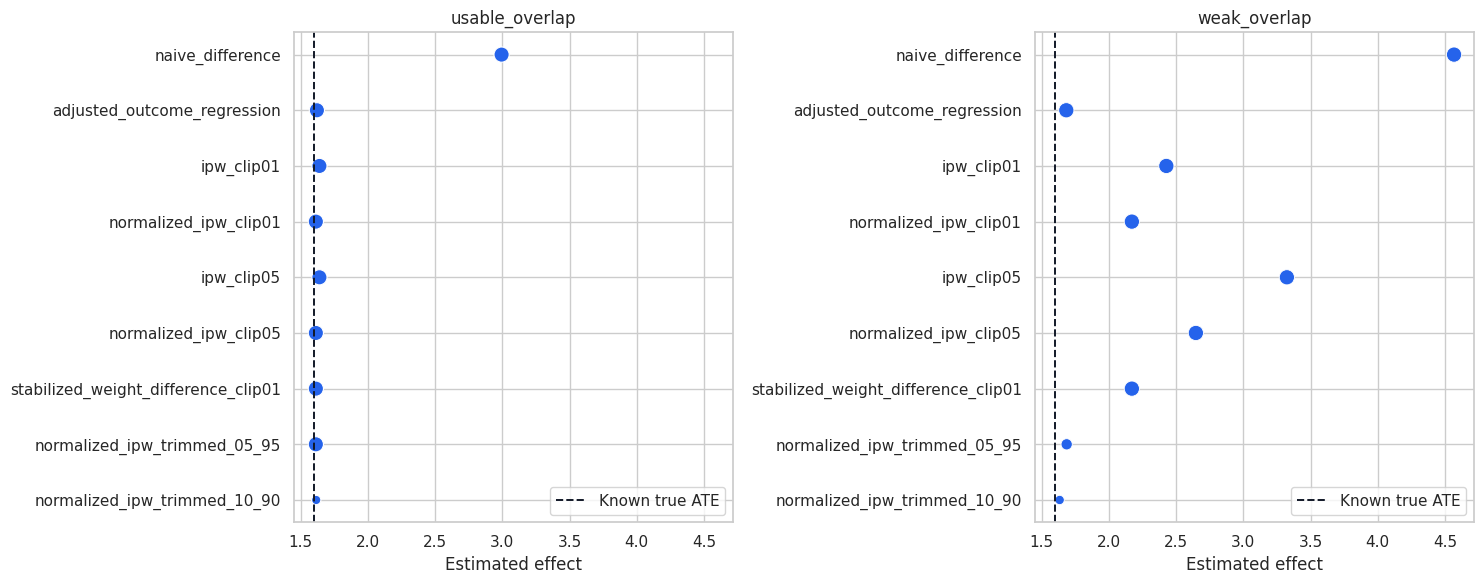

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True)
for ax, scenario in zip(axes, ["usable_overlap", "weak_overlap"]):
    scenario_plot = weighted_estimates.query("scenario == @scenario").copy()
    sns.scatterplot(
        data=scenario_plot,
        x="estimate",
        y="estimator",
        size="share_rows_used",
        sizes=(45, 120),
        color="#2563eb",
        legend=False,
        ax=ax,
    )
    ax.axvline(TRUE_ATE, color="#111827", linestyle="--", linewidth=1.4, label="Known true ATE")
    ax.set_title(scenario)
    ax.set_xlabel("Estimated effect")
    ax.set_ylabel("")
    ax.legend(loc="lower right")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "05_weighted_estimate_comparison.png", dpi=160, bbox_inches="tight")
plt.show()


The weak-overlap panel should look less stable. The point sizes show how much data each trimmed estimator kept; trimming can reduce variance but changes the population being described.


#### Trimming Changes the Target Population

Trimming is more than a technical cleanup. It removes units from the tails of the propensity distribution, which often removes users with more extreme baseline profiles.

The code below summarizes how baseline covariates change after trimming.


In [13]:
trim_rows = []
for scenario, scenario_df in weighted_df.groupby("scenario"):
    for sample_name, mask in [
        ("full_sample", np.ones(len(scenario_df), dtype=bool)),
        ("trim_05_95", scenario_df["estimated_propensity"].between(0.05, 0.95).to_numpy()),
        ("trim_10_90", scenario_df["estimated_propensity"].between(0.10, 0.90).to_numpy()),
    ]:
        sample = scenario_df.loc[mask]
        trim_rows.append(
            {
                "scenario": scenario,
                "sample": sample_name,
                "rows": len(sample),
                "share_rows": len(sample) / len(scenario_df),
                "treatment_rate": sample["feature_exposure"].mean(),
                "mean_user_engagement": sample["user_engagement"].mean(),
                "mean_baseline_value": sample["baseline_value"].mean(),
                "mean_estimated_propensity": sample["estimated_propensity"].mean(),
            }
        )
trim_population_summary = pd.DataFrame(trim_rows)
trim_population_summary.to_csv(TABLE_DIR / "05_trimming_population_summary.csv", index=False)
trim_population_summary


,scenario,sample,rows,share_rows,treatment_rate,mean_user_engagement,mean_baseline_value,mean_estimated_propensity
0,usable_overlap,full_sample,5000,1.0000,0.467800,-0.006542,2.513019,0.467882
1,usable_overlap,trim_05_95,5000,1.0000,0.467800,-0.006542,2.513019,0.467882
2,usable_overlap,trim_10_90,4993,0.9986,0.467855,-0.004857,2.514952,0.468083
3,weak_overlap,full_sample,5000,1.0000,0.626000,0.010718,2.515658,0.626021
4,weak_overlap,trim_05_95,3260,0.6520,0.551840,-0.251799,2.142311,0.552169
5,weak_overlap,trim_10_90,2597,0.5194,0.535233,-0.279770,2.083192,0.534518


The trimmed sample may have lower or higher average baseline characteristics than the full sample. That means the trimmed estimate is often more stable but applies to a more comparable subpopulation.




#### DoWhy Weighting Under Usable and Weak Overlap

Now we run DoWhy's `backdoor.propensity_score_weighting` estimator under the same graph in both scenarios. This connects the manual diagnostics to DoWhy's estimator interface.


In [14]:
# Define reusable helpers for the DoWhy Weighting Under Usable And Weak Overlap section.
estimator_edges = [
    ("user_engagement", "feature_exposure"),
    ("user_engagement", "weekly_value"),
    ("prior_sessions", "feature_exposure"),
    ("prior_sessions", "weekly_value"),
    ("account_age_weeks", "feature_exposure"),
    ("account_age_weeks", "weekly_value"),
    ("is_power_user", "feature_exposure"),
    ("is_power_user", "weekly_value"),
    ("baseline_value", "feature_exposure"),
    ("baseline_value", "weekly_value"),
    ("feature_exposure", "weekly_value"),
]
def edges_to_dot(edges):
    """
    Idea: Convert an edge table into DOT graph syntax for DoWhy or Graphviz-style display.
    
    Parameters
    ----------
    edges : object
        Collection of graph edges to draw, compare, or convert into a table.
    
    Returns
    -------
    str
        DOT graph string that can be passed to DoWhy or Graphviz-style renderers.
    """
    lines = ["digraph {"]
    for source, target in edges:
        lines.append(f"    {source} -> {target};")
    lines.append("}")
    return chr(10).join(lines)
dowhy_graph = edges_to_dot(estimator_edges)
dowhy_rows = []
for scenario, scenario_df in overlap_df.groupby("scenario"):
    dowhy_data = scenario_df.drop(columns=["scenario", "true_propensity"]).copy()
    model = CausalModel(
        data=dowhy_data,
        treatment="feature_exposure",
        outcome="weekly_value",
        graph=dowhy_graph,
    )
    estimand = model.identify_effect(proceed_when_unidentifiable=True)
    for label, method_name in [
        ("dowhy_linear_regression", "backdoor.linear_regression"),
        ("dowhy_propensity_score_weighting", "backdoor.propensity_score_weighting"),
    ]:
        estimate = model.estimate_effect(estimand, method_name=method_name)
        dowhy_rows.append(
            {
                "scenario": scenario,
                "estimator": label,
                "method_name": method_name,
                "reported_common_causes": ", ".join(model.get_common_causes()),
                "estimate": float(estimate.value),
                "absolute_error_vs_true_ate": abs(float(estimate.value) - TRUE_ATE),
            }
        )
dowhy_weighting_comparison = pd.DataFrame(dowhy_rows)
dowhy_weighting_comparison.to_csv(TABLE_DIR / "05_dowhy_weighting_comparison.csv", index=False)
dowhy_weighting_comparison


,scenario,estimator,method_name,reported_common_causes,estimate,absolute_error_vs_true_ate
0,usable_overlap,dowhy_linear_regression,backdoor.linear_regression,"baseline_value, account_age_weeks, user_engagement, prior_sessions, is_power_user",1.620507,0.020507
1,usable_overlap,dowhy_propensity_score_weighting,backdoor.propensity_score_weighting,"baseline_value, account_age_weeks, user_engagement, prior_sessions, is_power_user",1.613681,0.013681
2,weak_overlap,dowhy_linear_regression,backdoor.linear_regression,"baseline_value, account_age_weeks, user_engagement, prior_sessions, is_power_user",1.683087,0.083087
3,weak_overlap,dowhy_propensity_score_weighting,backdoor.propensity_score_weighting,"baseline_value, account_age_weeks, user_engagement, prior_sessions, is_power_user",2.646674,1.046674


DoWhy uses the same graph in both scenarios. If the weighting estimate is less stable in the weak-overlap scenario, the issue is not graph identification; it is support and weighting fragility.


#### Plot DoWhy Estimates Against Manual Diagnostics

This plot shows DoWhy's regression and weighting estimates next to the known ATE.


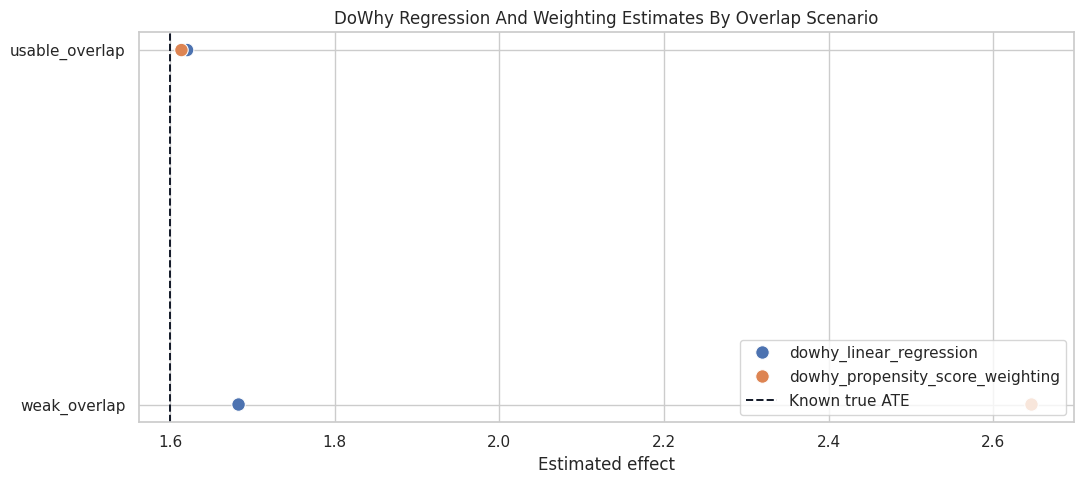

In [15]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.scatterplot(
    data=dowhy_weighting_comparison,
    x="estimate",
    y="scenario",
    hue="estimator",
    s=95,
    ax=ax,
)
ax.axvline(TRUE_ATE, color="#111827", linestyle="--", linewidth=1.4, label="Known true ATE")
ax.set_title("DoWhy Regression And Weighting Estimates By Overlap Scenario")
ax.set_xlabel("Estimated effect")
ax.set_ylabel("")
ax.legend(loc="lower right")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "05_dowhy_weighting_comparison.png", dpi=160, bbox_inches="tight")
plt.show()


The DoWhy weighting estimate can drift in weak overlap for the same reason manual IPW drifts: extreme propensities create extreme influence. A clean API call does not remove the need for overlap diagnostics.




#### Practical Decision Guide

This table summarizes what to do when weighting diagnostics look good, borderline, or poor.


| diagnostic_pattern | reasonable_next_step | caution |
| --- | --- | --- |
| Good overlap, small weights, improved balance | Report IPW or normalized IPW alongside regression and balance diagnostics. | Still depends on observed-confounding assumptions. |
| Moderate tails but acceptable effective sample size | Compare clipped, stabilized, and normalized weights; report sensitivity to trimming. | Make clear whether trimming changes the target population. |
| Extreme weights and small effective sample size | Avoid relying on raw IPW alone; consider trimming, overlap weights, redesign, or narrower estimand. | The full-population ATE may not be well supported by observed data. |
| Balance remains poor after weighting | Revisit the propensity model and graph assumptions before interpreting the estimate. | A weighted estimate without balance is not reassuring. |


This is the practical mindset: weighting is only credible when the weighted comparison is both balanced and supported by enough observations.

That makes the comparison interpretable because differences across methods can be tied to estimator behavior while preprocessing and evaluation stay fixed.
<!-- result-implication-expanded -->




#### Final Summary

This final table gives a compact report-ready summary of the lesson's lessons.


In [16]:
usable_norm = weighted_estimates.query("scenario == 'usable_overlap' and estimator == 'normalized_ipw_clip01'")["estimate"].iloc[0]
weak_norm = weighted_estimates.query("scenario == 'weak_overlap' and estimator == 'normalized_ipw_clip01'")["estimate"].iloc[0]
usable_ess = weight_diagnostics.query("scenario == 'usable_overlap' and weight_column == 'ipw_weight_clip01'")["effective_sample_size"].iloc[0]
weak_ess = weight_diagnostics.query("scenario == 'weak_overlap' and weight_column == 'ipw_weight_clip01'")["effective_sample_size"].iloc[0]
final_summary = pd.DataFrame(
    [
        {"item": "Causal question", "summary": "Average effect of feature exposure on weekly value."},
        {"item": "Known true ATE", "summary": f"{TRUE_ATE:.3f}"},
        {"item": "Usable-overlap normalized IPW", "summary": f"{usable_norm:.3f}; effective sample size about {usable_ess:.0f}."},
        {"item": "Weak-overlap normalized IPW", "summary": f"{weak_norm:.3f}; effective sample size about {weak_ess:.0f}."},
        {"item": "Main diagnostic lesson", "summary": "Weak overlap creates large weights and makes weighting estimates more fragile."},
        {"item": "Trimming lesson", "summary": "Trimming can stabilize estimates but changes the population being described."},
        {"item": "DoWhy lesson", "summary": "DoWhy can estimate weighted effects, but overlap diagnostics remain the analyst's responsibility."},
        {"item": "Main limitation", "summary": "All weighting estimators still depend on measured common causes and adequate support."},
    ]
)
final_summary.to_csv(TABLE_DIR / "05_final_weighting_summary.csv", index=False)
final_summary


,item,summary
0,Causal question,Average effect of feature exposure on weekly value.
1,Known true ATE,1.600
2,Usable-overlap normalized IPW,1.613; effective sample size about 4328.
3,Weak-overlap normalized IPW,2.171; effective sample size about 1020.
4,Main diagnostic lesson,Weak overlap creates large weights and makes weighting estimates more fragile.
5,Trimming lesson,Trimming can stabilize estimates but changes the population being described.
6,DoWhy lesson,"DoWhy can estimate weighted effects, but overlap diagnostics remain the analyst's responsibility."
7,Main limitation,All weighting estimators still depend on measured common causes and adequate support.


The key point is not that weighting is good or bad. Weighting is useful when the data support the comparison. When overlap is weak, the responsible answer may be a narrower estimand, a trimmed population, or a redesign of the analysis.


#### Student Exercises

Try these after running the lesson:

1. Increase `treatment_selection_strength` in the weak-overlap dataset and watch the effective sample size fall.
2. Change the clipping thresholds from `[0.01, 0.99]` to `[0.02, 0.98]` and compare estimates.
3. Compare trimming bands `[0.05, 0.95]`, `[0.10, 0.90]`, and `[0.20, 0.80]`.
4. Add a nonlinear term to the propensity model and see whether balance improves.
5. Remove one confounder from the propensity model and inspect both balance and bias.
6. Write a short stakeholder summary explaining why a full-population ATE may not be supported under weak overlap.


## Closing Notes

This section shows that inverse propensity weighting is more than a formula. It requires overlap, reasonable weights, adequate effective sample size, and improved covariate balance. The sequence next moves beyond backdoor weighting and introduces frontdoor, instrumental-variable, and natural-experiment logic.
